In [11]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Times New Roman"

In [35]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import defaultdict, Counter
from sklearn.feature_extraction.text import TfidfVectorizer

### Zbiór danych

`https://www.kaggle.com/datasets/suchintikasarkar/sentiment-analysis-for-mental-health`

Zadanie: **Klasyfikacja stanu psychicznego na podstawie tekstu**

In [2]:
# pobranie i wczytanie danych
path = kagglehub.dataset_download("suchintikasarkar/sentiment-analysis-for-mental-health")
file_path = os.path.join(path, 'Combined Data.csv')
df = pd.read_csv(file_path)

df = df.drop(columns=['Unnamed: 0'])
df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


In [3]:
# sprawdzenie braków w kolumnach
df.isnull().sum()

statement    362
status         0
dtype: int64

...

In [4]:
missing_percent = df.isnull().mean() * 100
missing_by_class = df[df['statement'].isnull()]['status'].value_counts()
total_by_class = df['status'].value_counts()

print(f"Brakujące dane stanowią ~{missing_percent['statement']:.2f}% całego zbioru.")
print("\nI dotyczą odpowiednio klas:")
for cls in missing_by_class.keys():
    cls_percent = (missing_by_class[cls]/total_by_class[cls])*100 
    print(f"{cls:<22} {missing_by_class[cls]:<3} przykładów ({cls_percent:.2f}% tej klasy)")

Brakujące dane stanowią ~0.68% całego zbioru.

I dotyczą odpowiednio klas:
Personality disorder   124 przykładów (10.32% tej klasy)
Bipolar                100 przykładów (3.48% tej klasy)
Stress                 82  przykładów (3.07% tej klasy)
Anxiety                47  przykładów (1.21% tej klasy)
Normal                 8   przykładów (0.05% tej klasy)
Suicidal               1   przykładów (0.01% tej klasy)


In [5]:
# czyszczenie brakujących danych
df = df.dropna(subset=['statement']).reset_index(drop=True)
total, _ = df.shape
print(f"Pozostało {total:,} przykładów.")

Pozostało 52,681 przykładów.


In [6]:
# podział na klasy (liczba przykładów)
count_by_class = df['status'].value_counts()
count_by_class

status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64

In [7]:
# podział na klasy (odsetek)
percent_by_class = df['status'].value_counts(normalize=True)*100
percent_by_class.round(2)

status
Normal                  31.02
Depression              29.24
Suicidal                20.22
Anxiety                  7.29
Bipolar                  5.27
Stress                   4.91
Personality disorder     2.04
Name: proportion, dtype: float64

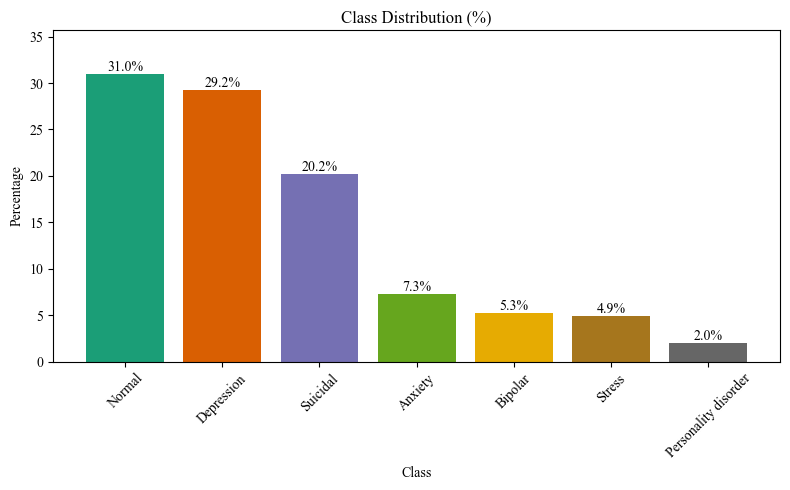

In [12]:
# podział na klasy (wizualizacja)
plt.figure(figsize=(8, 5))
colors = plt.cm.Dark2(np.linspace(0, 1, len(percent_by_class)))
bars = plt.bar(percent_by_class.index, percent_by_class.values, color=colors)

plt.title("Class Distribution (%)")
plt.xlabel("Class")
plt.ylabel("Percentage")
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.1f}%',
             ha='center', va='bottom')
plt.ylim(0, percent_by_class.max()*1.15)
plt.tight_layout()
plt.show()

In [13]:
# średnia długość tekstu (liczba znaków) per klasa
df['length'] = df['statement'].str.len()
avg_length_by_class = df.groupby('status')['length'].mean().sort_values(ascending=False)
avg_length_by_class.round(1)

status
Personality disorder    956.7
Bipolar                 946.1
Depression              844.0
Anxiety                 764.7
Suicidal                735.0
Stress                  613.5
Normal                   90.2
Name: length, dtype: float64

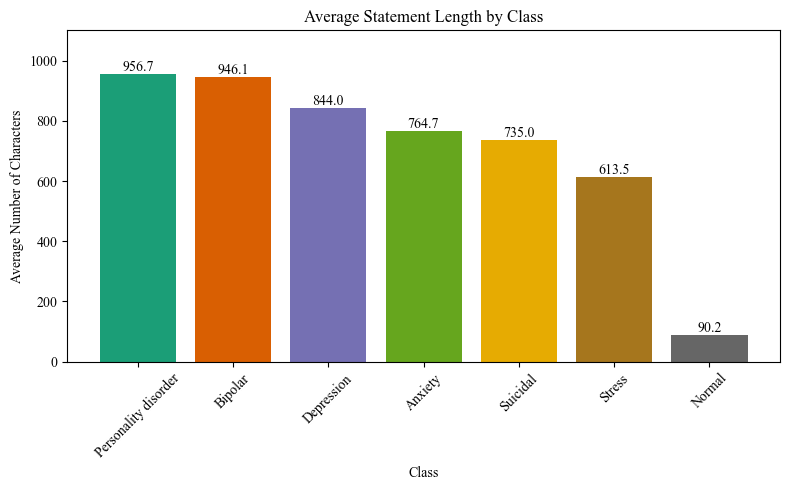

In [14]:
# średnia długość tekstu (liczba znaków) per klasa (wizualizacja)
plt.figure(figsize=(8, 5))

colors = plt.cm.Dark2(np.linspace(0, 1, len(avg_length_by_class)))
bars = plt.bar(avg_length_by_class.index, avg_length_by_class.values, color=colors)

plt.title("Average Statement Length by Class")
plt.xlabel("Class")
plt.ylabel("Average Number of Characters")

plt.xticks(rotation=45)
plt.ylim(0, avg_length_by_class.max() * 1.15)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.1f}',
             ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [15]:
normal = df[df['status'] == 'Normal']['statement'].head(10)
print("Przykłady z klasy 'Normal':")
for id, statement in enumerate(normal, 1):
    print(f"{id}) {statement}")

Przykłady z klasy 'Normal':
1) Gr gr dreaming of ex crush to be my game, God
2) wkwkwk what a joke
3) Leaves are also standby in front of the PC ... because the office is no longer on leave
4) Thank God even though it's just a ride through
5) wedding teaser concept using the song day6 - only, sounds good ga siiih
6) No comeback~
7) sender my sc on weirdðŸ˜«
8) 1.7 fucking years
9) Bismillah for Eid 2021, you get a few questions, you get a lot of THR
10) why is the call to prayer taking so long?


Przykłady z klasy 'Normal':
1) Gr gr dreaming of ex crush to be my game, God


2) wkwkwk what a joke


3) Leaves are also standby in front of the PC ... because the office is no longer on leave


4) Thank God even though it's just a ride through


5) wedding teaser concept using the song day6 - only, sounds good ga siiih


6) No comeback~


7) sender my sc on weirdðŸ˜«


8) 1.7 fucking years


9) Bismillah for Eid 2021, you get a few questions, you get a lot of THR


10) why is the call to prayer taking so long?

In [16]:
normal = df[df['status'] == 'Depression']['statement'].head(10)
print("Przykłady z klasy 'Depression':")
for id, statement in enumerate(normal, 1):
    print(f"{id}) {statement}")

Przykłady z klasy 'Depression':
1) I recently went through a breakup and she said she still wants to be friends so I said I can try doing that but when she talks to me about things it always hurts. I just want to lose feelings so all this pain can stop it hurts so much and I cannot even cry about it. I do not want to hurt her because she said she does not want to never speak to me again but I do not know what to do here. When we were together she always hurt me so I do not know why I still love her. I wish we never met it would be much less painful How do I lose feelings?
2) I do not know how to navigate these feelings, not that its a new feeling by any stretch. I just do not understand how I can go on from being so pleasantly fine to suicidal and self loathing within in minutes and not be able to step out of it. I have been suffering from poor mental health for over 10 years and I am about to turn 26 next week and I feel so ashamed for how serious my negative thoughts are. Covid was a

Przykłady z klasy 'Depression':
1) I recently went through a breakup and she said she still wants to be friends so I said I can try doing that but when she talks to me about things it always hurts. I just want to lose feelings so all this pain can stop it hurts so much and I cannot even cry about it. I do not want to hurt her because she said she does not want to never speak to me again but I do not know what to do here. When we were together she always hurt me so I do not know why I still love her. I wish we never met it would be much less painful How do I lose feelings?


2) I do not know how to navigate these feelings, not that its a new feeling by any stretch. I just do not understand how I can go on from being so pleasantly fine to suicidal and self loathing within in minutes and not be able to step out of it. I have been suffering from poor mental health for over 10 years and I am about to turn 26 next week and I feel so ashamed for how serious my negative thoughts are. Covid was a hard transition especially having moved to a new city a few months before everything started locking down, but now I am here and settled and I have a loving partner, a great connection to their family, a really fun job and I finished my degree. But when I stop and look around I feel like nothing will ever be good enough for me and I will never be good enough, I will always have skin problems and bad teeth and acne. I will never be the artist I used to be (I have a Bachelor in fine art) because I do not have the same drive or passionate that I used to have for it. I will never have the career I built my entire plan around because I am losing my interest in art. I will never have the relationship with my family that I want because I could not stand to stay in my hometown. All I can feel is this tornado of my failures swirling around me all the damn time. It just seems that no matter how many positives come my way they do not last long enough to out weight the negatives. I do not really know what I am looking for I guess I just wanted to say this out loud, or whatever. 0 to 100


3) So I have been with my bf for 5 months , and he already told me he was depressed. To this week nothing particular happened, but i can now feel hes bothered by it. He does not ask me to sleep together, do things and etcI know I am not the problem I am aware of that, I just wanted to ask: how can I be there without suffocating him? I am really clingy, a thing which he usually loves about me but right now I kind of have a feeling that I am doing too much.Any suggestion will be gladly accepted, be frank and tell me how I can not make it worse: its that that bothers me. My bf (21) is having a bad time due to his depression


4) My mom made me go to a camp that she knows I hate. Now I hate most days the only good time is at midnight where I can think to myself, but I do not want to call CPS because she does small things but they build up and I do not want to be taken away from my dog. So does it get better? Does it get better


5) Help me for ideas simple healthy meals to make when you feel depressed Simple meals when feeling depressed

In [30]:
stop_words = set(stopwords.words('english'))

def tokenize(text):
    tokens = word_tokenize(text.lower())
    return [token for token in tokens 
            if token not in stop_words
            and token.isalpha()]

In [31]:
vocab_by_class = defaultdict(set)

for label in df['status'].unique():
    texts = df[df['status'] == label]['statement']
    for text in texts:
        tokens = tokenize(text)
        vocab_by_class[label].update(tokens)

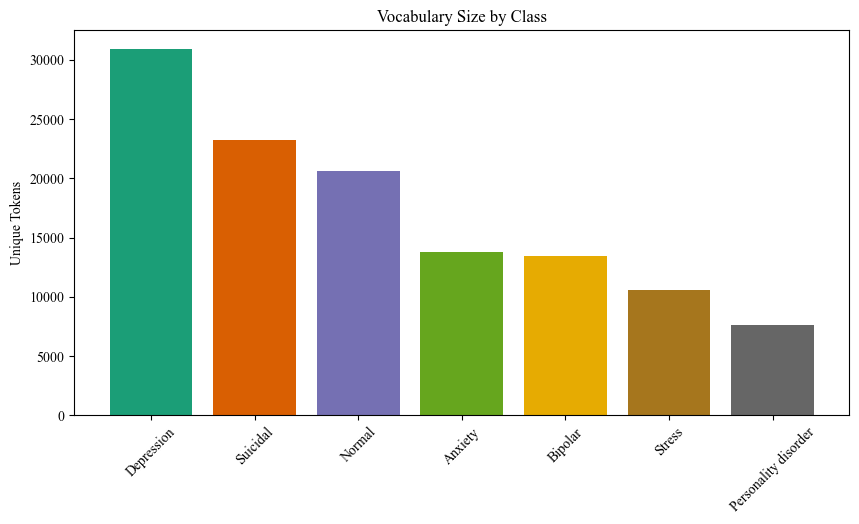

In [32]:
plt.figure(figsize=(10,5))

sorted_vocab = sorted(
    vocab_by_class.items(),
    key=lambda x: len(x[1]),
    reverse=True
)

classes = [cls for cls, vocab in sorted_vocab]
sizes = [len(vocab) for cls, vocab in sorted_vocab]

colors = plt.cm.Dark2(np.linspace(0, 1, len(classes)))

plt.bar(classes, sizes, color=colors)

plt.title("Vocabulary Size by Class")
plt.ylabel("Unique Tokens")
plt.xticks(rotation=45)

plt.show()

In [33]:
top_words_by_class = {}

for label in df['status'].unique():
    texts = df[df['status'] == label]['statement']
    tokens = []
    for text in texts:
        tokens.extend(tokenize(text))
    counter = Counter(tokens)
    top_words_by_class[label] = counter.most_common(10)

In [34]:
for label, words in top_words_by_class.items():
    print(f"\n=== {label} ===")
    for word, count in words:
        print(f"{word:<20}: {count}")


=== Anxiety ===
anxiety             : 3725
like                : 3276
feel                : 2284
get                 : 1984
know                : 1852
time                : 1630
really              : 1603
something           : 1274
back                : 1267
even                : 1223

=== Normal ===
like                : 1235
want                : 1120
get                 : 874
really              : 860
time                : 809
one                 : 757
go                  : 755
know                : 736
good                : 677
would               : 651

=== Depression ===
like                : 18277
feel                : 16539
want                : 12124
life                : 11130
know                : 10833
get                 : 9992
even                : 9171
time                : 8318
people              : 7903
would               : 7418

=== Suicidal ===
want                : 10640
like                : 9116
life                : 7700
feel                : 7520
know         

| Anxiety | Normal | Depression | Suicidal | Stress | Bipolar | Personality disorder |
|---|---|---|---|---|---|---|
| anxiety (3725) | like (1235) | like (18277) | want (10640) | like (1725) | like (3028) | like (1680) |
| like (3276) | want (1120) | feel (16539) | like (9116) | stress (1490) | feel (2388) | people (1248) |
| feel (2284) | get (874) | want (12124) | life (7700) | feel (1338) | bipolar (1837) | feel (1101) |
| get (1984) | really (860) | life (11130) | feel (7520) | get (1207) | get (1814) | even (795) |
| know (1852) | time (809) | know (10833) | know (6545) | know (1023) | know (1787) | know (788) |
| time (1630) | one (757) | get (9992) | would (5729) | time (1011) | time (1496) | get (637) |
| really (1603) | go (755) | even (9171) | get (5223) | even (805) | really (1494) | want (626) |
| something (1274) | know (736) | time (8318) | even (5180) | work (790) | want (1306) | avpd (602) |
| back (1267) | good (677) | people (7903) | people (4754) | really (773) | even (1107) | life (600) |
| even (1223) | would (651) | would (7418) | anymore (4416) | help (706) | life (1098) | really (596) |

In [36]:
documents = []
labels = []

for label in df['status'].unique():
    texts = df[df['status'] == label]['statement']
    combined_text = " ".join(texts)
    documents.append(combined_text)
    labels.append(label)

In [ ]:
vectorizer = TfidfVectorizer(
    stop_words='english'
)
X = vectorizer.fit_transform(documents)

In [38]:
feature_names = vectorizer.get_feature_names_out()

for i, label in enumerate(labels):
    scores = X[i].toarray().flatten()
    top_indices = scores.argsort()[-10:][::-1]
    top_words = [feature_names[idx] for idx in top_indices]
    print(f"\n=== {label} ===")
    print(top_words)


=== Anxiety ===
['anxiety', 'just', 'like', 've', 'feel', 'don', 'know', 'time', 'really', 'going']

=== Normal ===
['just', 'like', 'want', 'don', 'really', 'ðÿ', 'time', 'know', 'good', 'people']

=== Depression ===
['just', 'like', 'feel', 'want', 'life', 'know', 'time', 'people', 'really', 'depression']

=== Suicidal ===
['just', 'want', 'like', 'life', 'feel', 'know', 'people', 'anymore', 'time', 'going']

=== Stress ===
['like', 'just', 'stress', 'feel', 'don', 've', 'time', 'know', 'work', 'really']

=== Bipolar ===
['just', 'like', 'feel', 've', 'don', 'bipolar', 'know', 'time', 'really', 'want']

=== Personality disorder ===
['like', 'just', 'people', 'don', 'feel', 'avpd', 'know', 've', 'want', 'life']


| Anxiety | Normal | Depression | Suicidal | Stress | Bipolar | Personality disorder |
|---|---|---|---|---|---|---|
| anxiety | just | just | just | like | just | like |
| just | like | like | want | just | like | just |
| like | want | feel | like | stress | feel | people |
| ve | don | want | life | feel | ve | don |
| feel | really | life | feel | don | don | feel |
| don | ðÿ | know | know | ve | bipolar | avpd |
| know | time | time | people | time | know | know |
| time | know | people | anymore | know | time | ve |
| really | good | really | time | work | really | want |
| going | people | depression | going | really | want | life |